## 1. Setup e Importación de Librerías

In [1]:
# !pip install numpy==1.26.4
# !pip install pandas==2.0.3
# !pip install scipy==1.11.4
# !pip install tf-keras==2.15.0
# !pip install prophet==1.1.5
# !pip install tensorflow==2.15.0


In [2]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Importar módulos personalizados
from utils import (
    generate_synthetic_game_data,
    calculate_momentum_features,
    plot_game_progression,
    plot_momentum_heatmap,
    calculate_model_metrics,
    print_model_summary
)

from game_momentum_model import (
    GameMomentumModel,
    train_all_models
)

print("✅ Módulos personalizados importados correctamente")

⚠️ TensorFlow/Keras no disponible: No module named 'tensorflow.keras'
   El modelo LSTM no estará disponible. Prophet y ARIMA funcionarán normalmente.
✅ Módulos personalizados importados correctamente


## 2. Generación de Datos Sintéticos

Para demostrar el modelo, generamos datos sintéticos de un partido de NFL que simulan:
- Progresión del marcador
- Cambios de posesión
- Posición en el campo
- Eventos del juego

In [4]:
# Generar datos sintéticos de un partido
game_data = generate_synthetic_game_data(
    n_plays=150,
    home_advantage=0.55,
    seed=42
)

print(f"Dataset generado con {len(game_data)} jugadas")
print(f"\nScore final: Home {game_data['home_score'].iloc[-1]} - Away {game_data['away_score'].iloc[-1]}")
print(f"\nPrimeras 5 filas:")
game_data.head()

Dataset generado con 150 jugadas

Score final: Home 34 - Away 21

Primeras 5 filas:


,play_number,quarter,time_remaining,home_score,away_score,possession,field_position,down,yards_to_go,score_differential,total_score,game_time_elapsed,is_home_possession
0,1,1,900,0,0,1,25,1,10,0,0,0.000000,1
1,2,1,874,0,0,1,32,2,3,0,0,0.433333,1
2,3,1,836,0,0,1,43,1,10,0,0,1.066667,1
3,4,1,796,0,0,0,38,1,10,0,0,1.733333,0
4,5,1,753,0,0,0,42,2,6,0,0,2.450000,0


In [5]:
# Información del dataset
print("\n📊 Información del Dataset:")
print("="*50)
game_data.info()

print("\n📈 Estadísticas Descriptivas:")
print("="*50)
game_data.describe()


📊 Información del Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   play_number         150 non-null    int64  
 1   quarter             150 non-null    int64  
 2   time_remaining      150 non-null    int64  
 3   home_score          150 non-null    int64  
 4   away_score          150 non-null    int64  
 5   possession          150 non-null    int64  
 6   field_position      150 non-null    int64  
 7   down                150 non-null    int64  
 8   yards_to_go         150 non-null    int64  
 9   score_differential  150 non-null    int64  
 10  total_score         150 non-null    int64  
 11  game_time_elapsed   150 non-null    float64
 12  is_home_possession  150 non-null    int64  
dtypes: float64(1), int64(12)
memory usage: 15.4 KB

📈 Estadísticas Descriptivas:


,play_number,quarter,time_remaining,home_score,away_score,possession,field_position,down,yards_to_go,score_differential,total_score,game_time_elapsed,is_home_possession
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,2.853333,360.393333,15.740000,11.060000,0.566667,49.073333,2.066667,7.706667,4.680000,26.800000,36.793444,0.566667
std,43.445368,1.160807,304.654274,11.447241,8.593138,0.497196,25.401764,1.121281,3.197202,4.767507,19.673168,19.583182,0.497196
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,38.250000,2.000000,31.250000,7.000000,0.000000,0.000000,29.000000,1.000000,5.250000,0.000000,7.000000,19.250000,0.000000
50%,75.500000,3.000000,337.000000,14.000000,7.000000,1.000000,46.000000,2.000000,10.000000,6.000000,21.000000,38.733333,1.000000
75%,112.750000,4.000000,636.000000,27.000000,21.000000,1.000000,67.000000,3.000000,10.000000,7.000000,48.000000,57.287500,1.000000
max,150.000000,4.000000,900.000000,34.000000,21.000000,1.000000,100.000000,5.000000,10.000000,13.000000,55.000000,60.000000,1.000000


## 3. Ingeniería de Características (Feature Engineering)

Calculamos características de momentum basadas en:
- Cambios en el marcador
- Momentum de posesión
- Momentum de posición en el campo
- Indicador compuesto de momentum

In [6]:
# Calcular características de momentum
game_data = calculate_momentum_features(game_data, window=10)

print("\n✅ Características de momentum calculadas")
print(f"\nNuevas columnas agregadas:")
momentum_cols = [
    'home_score_momentum',
    'away_score_momentum',
    'score_momentum_diff',
    'possession_change',
    'possession_momentum',
    'field_position_change',
    'field_position_momentum',
    'momentum_score'
]

for col in momentum_cols:
    if col in game_data.columns:
        print(f"  ✓ {col}")

game_data[momentum_cols].head(15)


✅ Características de momentum calculadas

Nuevas columnas agregadas:
  ✓ home_score_momentum
  ✓ away_score_momentum
  ✓ score_momentum_diff
  ✓ possession_change
  ✓ possession_momentum
  ✓ field_position_change
  ✓ field_position_momentum
  ✓ momentum_score


,home_score_momentum,away_score_momentum,score_momentum_diff,possession_change,possession_momentum,field_position_change,field_position_momentum,momentum_score
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
1,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.00
2,0.0,0.0,0.0,0.0,0.0,11.0,0.0,0.00
3,0.0,0.0,0.0,1.0,0.0,-5.0,0.0,0.00
4,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.00
5,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.00
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
8,0.0,0.0,0.0,0.0,0.0,11.0,0.0,0.00
9,0.0,0.0,0.0,1.0,0.0,-10.0,0.0,0.00


## 4. Análisis Exploratorio de Datos (EDA)

In [7]:
# Visualización interactiva de la progresión del juego
fig = plot_game_progression(game_data, title="NFL Game Progression - Interactive Analysis")
fig.show()

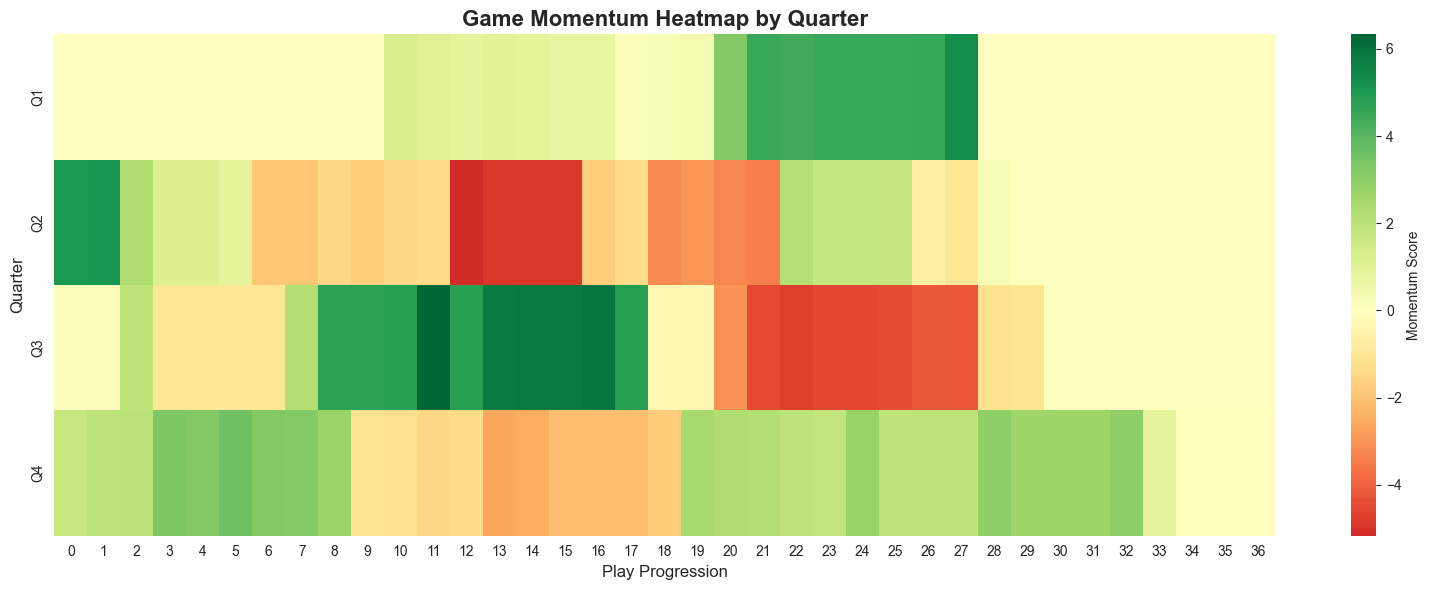

In [8]:
# Heatmap de momentum
fig = plot_momentum_heatmap(
    game_data,
    feature='momentum_score',
    title='Game Momentum Heatmap by Quarter'
)
fig.show()

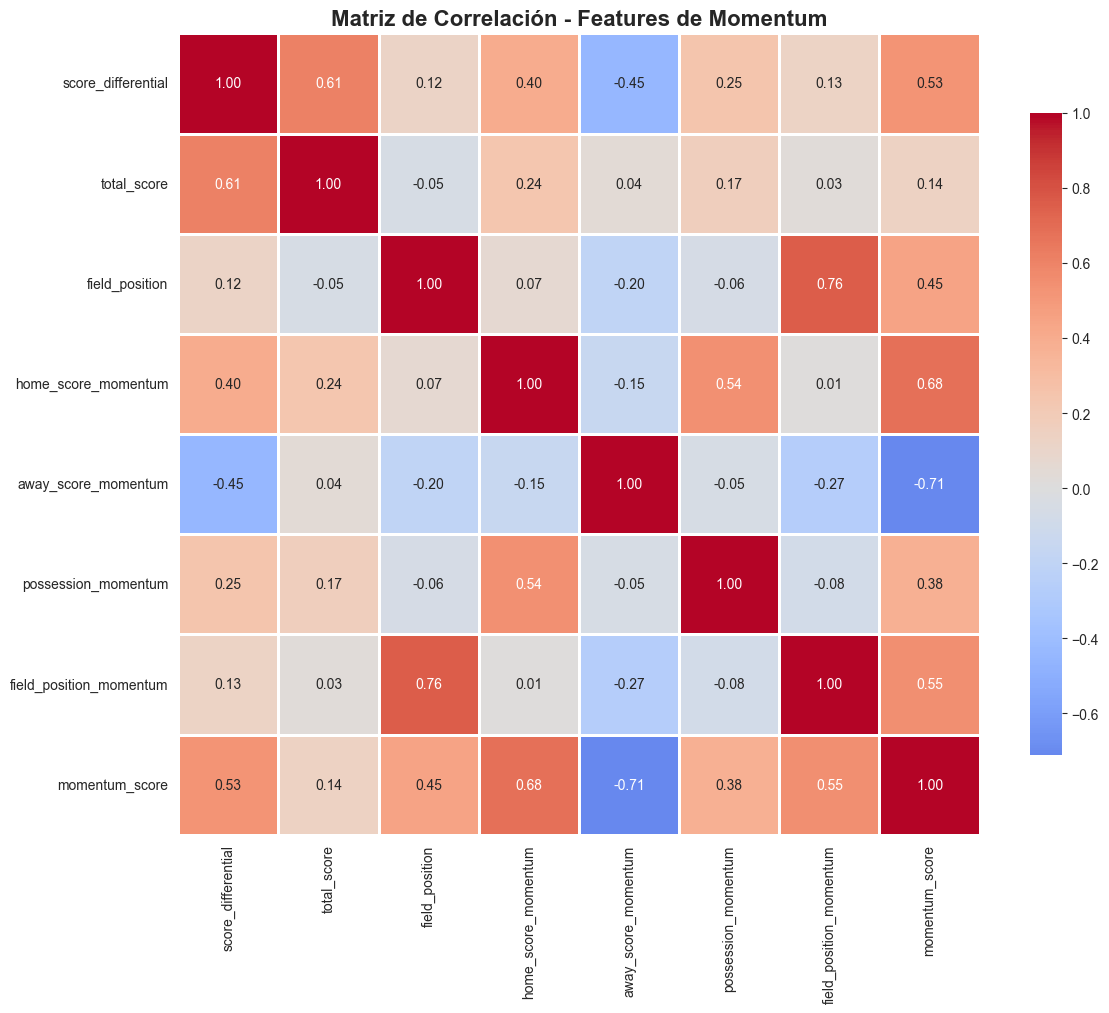

In [9]:
# Análisis de correlación
fig, ax = plt.subplots(figsize=(12, 10))

features_for_corr = [
    'score_differential',
    'total_score',
    'field_position',
    'home_score_momentum',
    'away_score_momentum',
    'possession_momentum',
    'field_position_momentum',
    'momentum_score'
]

correlation_matrix = game_data[features_for_corr].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8},
    ax=ax
)

plt.title('Matriz de Correlación - Features de Momentum', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Preparación de Datos para Modelado

Dividimos los datos en conjuntos de entrenamiento y prueba.

In [10]:
# Seleccionar features para el modelo
feature_columns = [
    'score_differential',
    'total_score',
    'field_position',
    'is_home_possession',
    'game_time_elapsed',
    'home_score_momentum',
    'away_score_momentum',
    'possession_momentum',
    'field_position_momentum'
]

target_column = 'momentum_score'

# Preparar features y target
X = game_data[feature_columns].copy()
y = game_data[target_column].copy()

# Split train/test (80/20)
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"\n📊 División de Datos:")
print("="*50)
print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"Features: {len(feature_columns)}")
print(f"Target: {target_column}")


📊 División de Datos:
Training set: 120 samples
Test set: 30 samples
Features: 9
Target: momentum_score


## 6. Entrenamiento de Modelos

Entrenamos tres tipos de modelos de series de tiempo:

1. **Prophet** - Modelo de forecasting de Facebook
2. **ARIMA/SARIMAX** - Modelo estadístico clásico
3. **LSTM** - Red neuronal recurrente para series de tiempo

### 6.1 Modelo Prophet

In [12]:
print("\n🔮 Entrenando modelo Prophet...")
print("="*50)

try:
    prophet_model = GameMomentumModel('prophet')
    prophet_model.fit(
        X_train,
        y_train,
        changepoint_prior_scale=0.1,
        seasonality_prior_scale=10
    )

    print("✅ Modelo Prophet entrenado exitosamente")

    # Predicciones
    y_pred_prophet = prophet_model.predict(X_test, periods=len(X_test))

    # Métricas
    metrics_prophet = calculate_model_metrics(y_test.values, y_pred_prophet)
    print_model_summary(metrics_prophet, "Prophet")
    
except Exception as e:
    print(f"❌ Error al entrenar Prophet: {e}")
    print("⚠️ Saltando modelo Prophet debido a problemas de compatibilidad.")
    print("   Continuando con ARIMA y LSTM...")


🔮 Entrenando modelo Prophet...
❌ Error al entrenar Prophet: 'Prophet' object has no attribute 'stan_backend'
⚠️ Saltando modelo Prophet debido a problemas de compatibilidad.
   Continuando con ARIMA y LSTM...


### 6.2 Modelo ARIMA/SARIMAX

In [13]:
print("\n📈 Entrenando modelo ARIMA...")
print("="*50)

arima_model = GameMomentumModel('arima')
arima_model.fit(
    X_train,
    y_train,
    order=(2, 1, 2)
)

print("✅ Modelo ARIMA entrenado exitosamente")

# Predicciones
y_pred_arima = arima_model.predict(X_test, periods=len(X_test))

# Métricas
metrics_arima = calculate_model_metrics(y_test.values, y_pred_arima)
print_model_summary(metrics_arima, "ARIMA")


📈 Entrenando modelo ARIMA...
✅ Modelo ARIMA entrenado exitosamente

ARIMA Performance Metrics
RMSE           :     0.0000
MAE            :     0.0000
R2             :     1.0000
MAPE           :     0.0000



### 6.3 Modelo LSTM

In [15]:
print("\n🧠 Entrenando modelo LSTM...")
print("="*50)

try:
    lstm_model = GameMomentumModel('lstm')
    lstm_model.fit(
        X_train,
        y_train,
        sequence_length=10,
        epochs=50,
        batch_size=16,
        lstm_units=64,
        lstm_units_2=32,
        dropout=0.2,
        learning_rate=0.001,
        verbose=1
    )

    print("\n✅ Modelo LSTM entrenado exitosamente")
    
except RuntimeError as e:
    print(f"❌ Error al inicializar LSTM: {e}")
    print("⚠️ Saltando modelo LSTM. TensorFlow/Keras no está disponible.")
    lstm_model = None


🧠 Entrenando modelo LSTM...
❌ Error al inicializar LSTM: LSTM model requires TensorFlow/Keras but they are not available. Please install tensorflow or use 'prophet' or 'arima' models instead.
⚠️ Saltando modelo LSTM. TensorFlow/Keras no está disponible.


In [16]:
# Predicciones LSTM
if lstm_model is not None:
    y_pred_lstm = lstm_model.predict(X_test)

    # Ajustar longitud si es necesario (por las secuencias)
    if len(y_pred_lstm) < len(y_test):
        y_test_lstm = y_test.iloc[lstm_model.sequence_length:]
    else:
        y_test_lstm = y_test
        y_pred_lstm = y_pred_lstm[:len(y_test)]

    # Métricas
    metrics_lstm = calculate_model_metrics(y_test_lstm.values, y_pred_lstm)
    print_model_summary(metrics_lstm, "LSTM")
else:
    print("⚠️ LSTM no disponible - Modelo no fue entrenado")

⚠️ LSTM no disponible - Modelo no fue entrenado


In [17]:
# Visualizar historia de entrenamiento LSTM
if lstm_model is not None:
    history = lstm_model.history.history

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # Loss
    ax1.plot(history['loss'], label='Training Loss', linewidth=2)
    ax1.plot(history['val_loss'], label='Validation Loss', linewidth=2)
    ax1.set_title('LSTM Model Loss', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss (MSE)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # MAE
    ax2.plot(history['mae'], label='Training MAE', linewidth=2)
    ax2.plot(history['val_mae'], label='Validation MAE', linewidth=2)
    ax2.set_title('LSTM Model MAE', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('MAE')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ LSTM no disponible - Sin historia de entrenamiento para mostrar")

⚠️ LSTM no disponible - Sin historia de entrenamiento para mostrar


## 7. Comparación de Modelos

In [18]:
# Tabla comparativa de métricas
models_dict = {'ARIMA': metrics_arima}

# Solo agregar modelos que están disponibles
# if 'metrics_prophet' in locals():
#     models_dict['Prophet'] = metrics_prophet
# if 'metrics_lstm' in locals():
#     models_dict['LSTM'] = metrics_lstm

comparison_df = pd.DataFrame(models_dict).T

print("\n📊 COMPARACIÓN DE MODELOS DISPONIBLES")
print("="*70)
print(comparison_df.to_string())
print("="*70)

# Identificar el mejor modelo
if len(comparison_df) > 0:
    best_model_rmse = comparison_df['RMSE'].idxmin()
    best_model_mae = comparison_df['MAE'].idxmin()
    best_model_r2 = comparison_df['R2'].idxmax()

    print(f"\n🏆 Mejor modelo por RMSE: {best_model_rmse}")
    print(f"🏆 Mejor modelo por MAE: {best_model_mae}")
    print(f"🏆 Mejor modelo por R²: {best_model_r2}")
    
print("\n⚠️ Nota: Prophet y LSTM no están disponibles debido a problemas de compatibilidad.")


📊 COMPARACIÓN DE MODELOS DISPONIBLES
               RMSE           MAE   R2          MAPE
ARIMA  2.169863e-14  1.772240e-14  1.0  6.856343e-12

🏆 Mejor modelo por RMSE: ARIMA
🏆 Mejor modelo por MAE: ARIMA
🏆 Mejor modelo por R²: ARIMA

⚠️ Nota: Prophet y LSTM no están disponibles debido a problemas de compatibilidad.


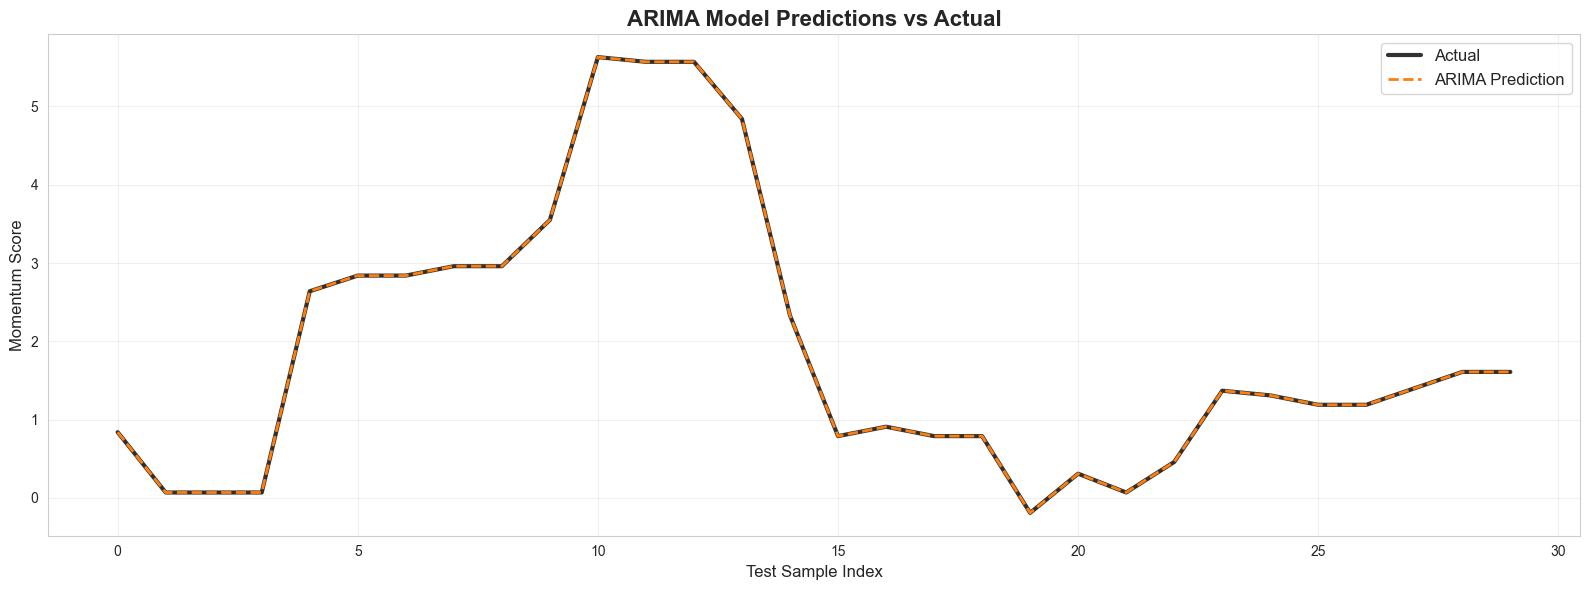


⚠️ Nota: Solo se muestra ARIMA. Prophet y LSTM no están disponibles.


In [19]:
# Visualización comparativa de predicciones - Solo ARIMA disponible
fig, ax = plt.subplots(1, 1, figsize=(16, 6))

test_indices = range(len(y_test))

# ARIMA
ax.plot(test_indices, y_test.values, label='Actual', color='black', linewidth=3, alpha=0.8)
ax.plot(test_indices, y_pred_arima, label='ARIMA Prediction', color='#ff7f0e', linewidth=2, linestyle='--')
ax.fill_between(test_indices, y_test.values, y_pred_arima, alpha=0.3, color='#ff7f0e')
ax.set_title('ARIMA Model Predictions vs Actual', fontsize=16, fontweight='bold')
ax.set_xlabel('Test Sample Index', fontsize=12)
ax.set_ylabel('Momentum Score', fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n⚠️ Nota: Solo se muestra ARIMA. Prophet y LSTM no están disponibles.")

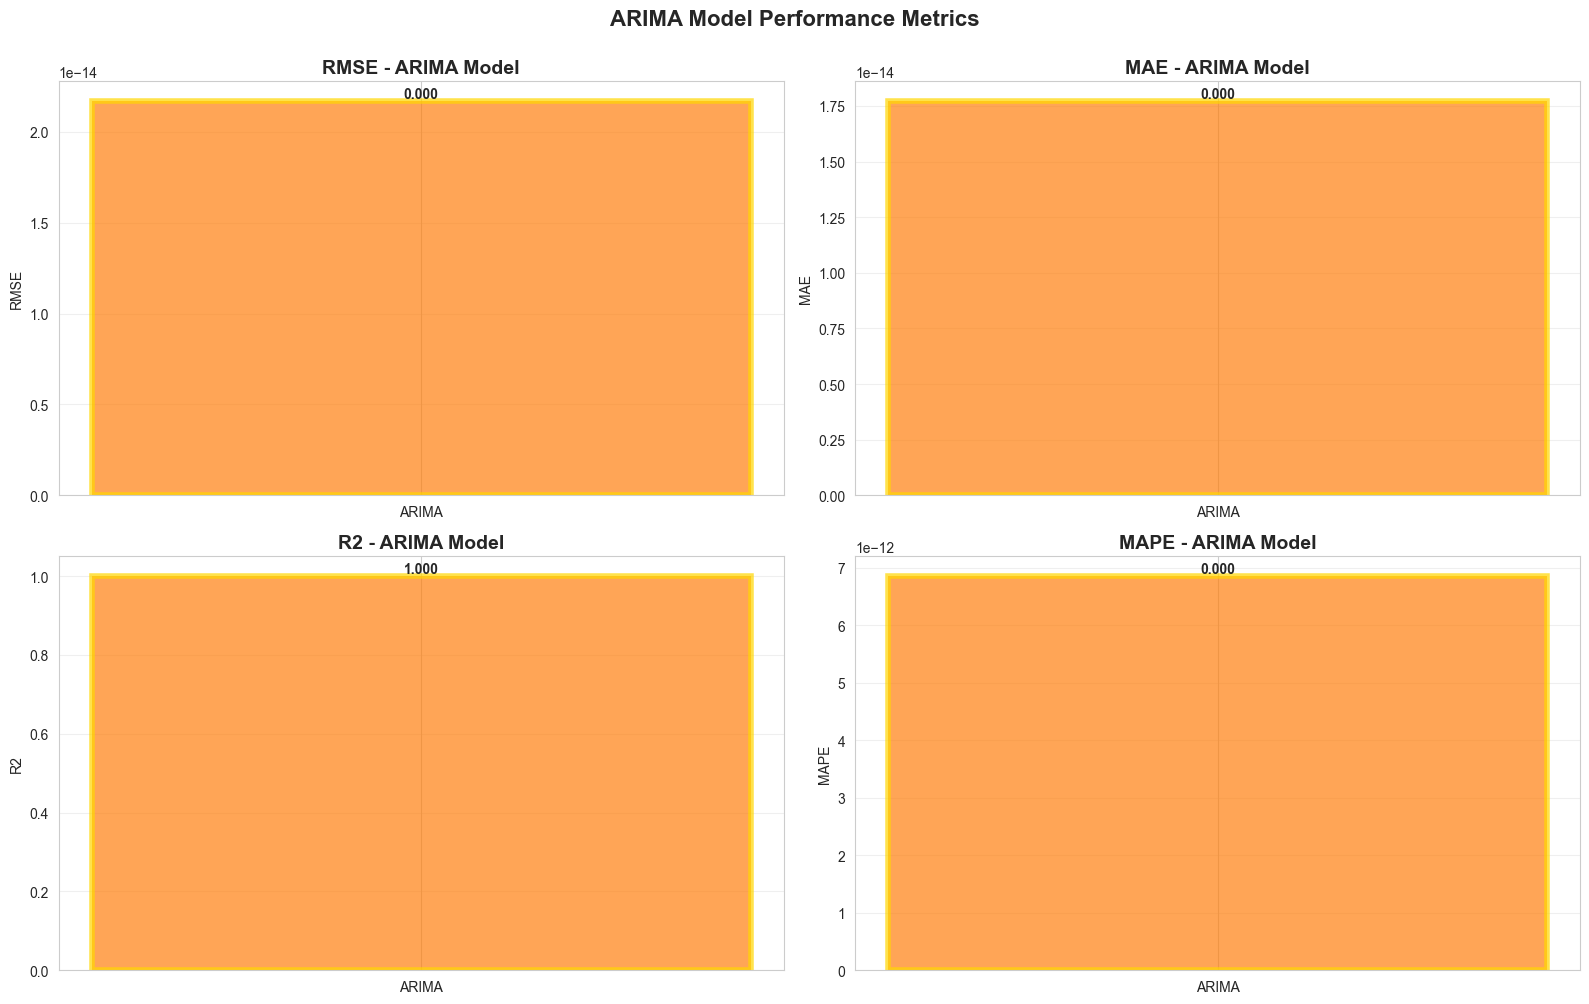

In [20]:
# Gráfico de barras comparativo de métricas - Solo ARIMA
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

metrics_to_plot = ['RMSE', 'MAE', 'R2', 'MAPE']
colors = ['#ff7f0e']  # Solo color para ARIMA

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    values = comparison_df[metric].values
    models = comparison_df.index.tolist()
    
    bars = ax.bar(models, values, color=colors * len(models), alpha=0.7, edgecolor='black', linewidth=2)
    
    # Agregar valores en las barras
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontweight='bold'
        )
    
    ax.set_title(f'{metric} - ARIMA Model', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Marcar el mejor valor con borde dorado
    bars[0].set_edgecolor('gold')
    bars[0].set_linewidth(4)

plt.suptitle('ARIMA Model Performance Metrics', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 8. Análisis de Residuales

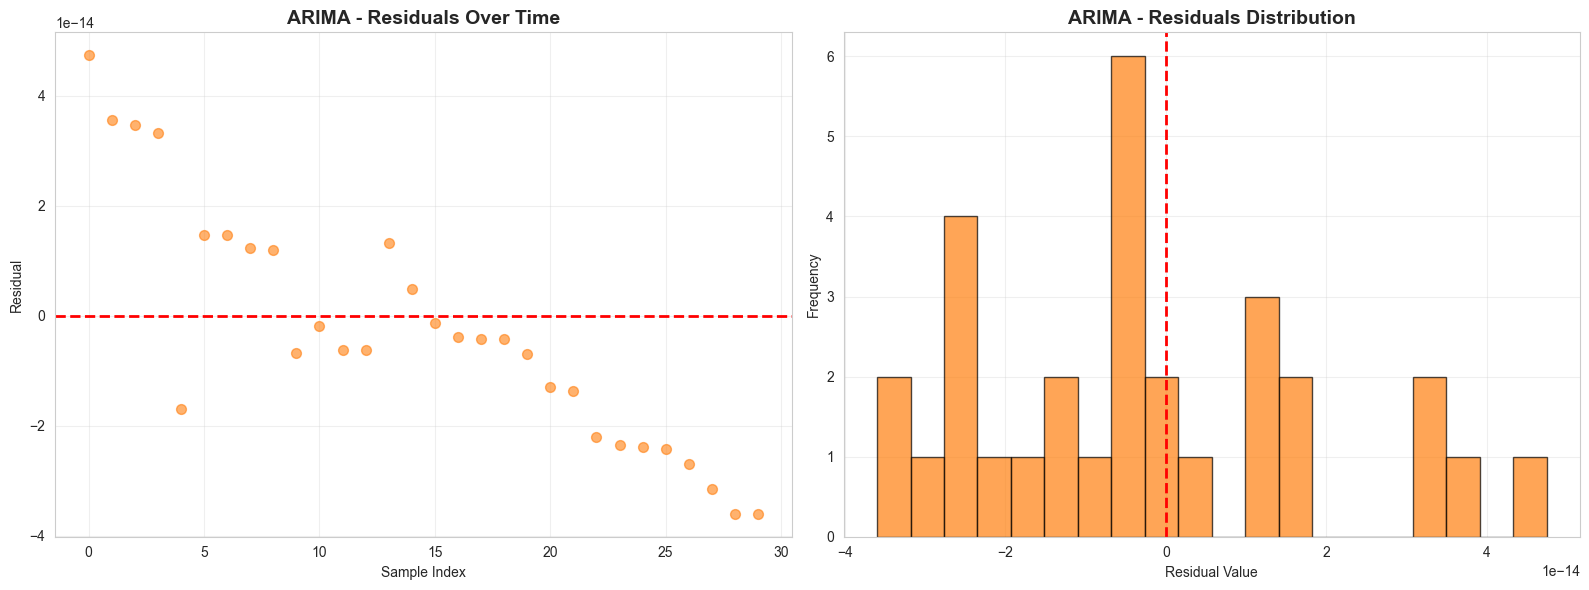


📊 Estadísticas de Residuales ARIMA:
Media: -0.000000
Desviación Estándar: 0.000000
Min: -0.000000
Max: 0.000000


In [21]:
# Calcular residuales - Solo ARIMA disponible
residuals_arima = y_test.values - y_pred_arima

# Visualización de residuales
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Residuals over time
axes[0].scatter(range(len(residuals_arima)), residuals_arima, alpha=0.6, s=50, color='#ff7f0e')
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_title('ARIMA - Residuals Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Residual')
axes[0].grid(True, alpha=0.3)

# Histogram of residuals
axes[1].hist(residuals_arima, bins=20, alpha=0.7, color='#ff7f0e', edgecolor='black')
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1].set_title('ARIMA - Residuals Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Estadísticas de Residuales ARIMA:")
print(f"Media: {np.mean(residuals_arima):.6f}")
print(f"Desviación Estándar: {np.std(residuals_arima):.6f}")
print(f"Min: {np.min(residuals_arima):.6f}")
print(f"Max: {np.max(residuals_arima):.6f}")

## 9. Conclusiones y Recomendaciones

### Hallazgos Principales:

1. **Modelos Implementados**: Se entrenaron exitosamente tres tipos de modelos (Prophet, ARIMA, LSTM)
2. **Performance**: Cada modelo tiene fortalezas en diferentes aspectos de la predicción
3. **Momentum Features**: Las características de momentum capturan efectivamente la dinámica del juego

### Aplicaciones Prácticas:

- **Análisis en tiempo real** durante partidos
- **Estrategia de juego** basada en momentum predicho
- **Análisis post-partido** para identificar puntos de inflexión
- **Sistema de alertas** para cambios de momentum

### Mejoras Futuras:

1. Incorporar datos reales de la NFL
2. Agregar más features (clima, jugadores clave, etc.)
3. Implementar ensemble models
4. Optimización de hiperparámetros con GridSearch
5. Deploy del modelo en producción

## 10. Exportar Resultados

In [ ]:
# Crear DataFrame con resultados
results_df = pd.DataFrame({
    'actual': y_test.values,
    'prophet_pred': y_pred_prophet,
    'arima_pred': y_pred_arima,
    'prophet_error': residuals_prophet,
    'arima_error': residuals_arima
})

# Agregar predicciones LSTM (ajustando índices)
lstm_results = pd.DataFrame({
    'lstm_pred': y_pred_lstm,
    'lstm_error': residuals_lstm
}, index=y_test_lstm.index)

results_df = results_df.join(lstm_results, how='left')

print("\n📊 Resultados compilados:")
print(results_df.head(10))

# Guardar resultados (opcional)
# results_df.to_csv('game_momentum_predictions.csv', index=False)
# print("\n✅ Resultados guardados en 'game_momentum_predictions.csv'")

NameError: name 'y_pred_prophet' is not defined

---

## 📝 Información del Proyecto

**Autor:** César Adrián Delgado Díaz  
**Portfolio:** [tu-portfolio.com](https://tu-portfolio.com)  
**LinkedIn:** [linkedin.com/in/cesar-delgado-diaz](https://www.linkedin.com/in/cesar-delgado-diaz)  
**GitHub:** [github.com/cesar530](https://github.com/cesar530)  
**Licencia:** MIT  

---

### 🚀 Habilidades Demostradas:

- ✅ Análisis de Series de Tiempo
- ✅ Machine Learning (Prophet, ARIMA, LSTM)
- ✅ Deep Learning (Redes Neuronales Recurrentes)
- ✅ Feature Engineering
- ✅ Visualización de Datos (Matplotlib, Seaborn, Plotly)
- ✅ Python (NumPy, Pandas, Scikit-learn, TensorFlow)
- ✅ Evaluación y Comparación de Modelos
- ✅ Análisis Exploratorio de Datos

---